<a href="https://colab.research.google.com/github/AreshaBasir/Physics_Informed_Neural_Network/blob/AreshaBasir-patch-1/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

getting ready with the environemnt & packages

In [2]:
# 1. Install the correct, modern packages
!pip install gymnasium minigrid pyvirtualdisplay
!sudo apt-get install -y xvfb ffmpeg

# 2. Updated Imports
import gymnasium as gym
# Notice the change here: it's just 'minigrid', not 'gymnasium_minigrid'
import minigrid
from minigrid.wrappers import *

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

# 3. Start Virtual Display
v_display = Display(visible=0, size=(1400, 900))
v_display.start()

  Using cached PyVirtualDisplay-3.0-py3-none-any.whl.metadata (943 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 3.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


Environment

In [3]:
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
obs, info = env.reset()
print("Environment loaded successfully!")

Environment loaded successfully!


PINN Architecture

In [4]:
class CostPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def physics_loss(model, coords):
    coords.requires_grad = True
    cost_pred = model(coords)


    grads = torch.autograd.grad(cost_pred, coords,
                                torch.ones_like(cost_pred),
                                create_graph=True)[0]


    smoothness_penalty = torch.mean(grads**2)
    return smoothness_penalty

MiniGrid PINN-Wrapper

In [5]:
class PhysicsAwareWrapper(gym.RewardWrapper):
    def __init__(self, env, pinn):
        super().__init__(env)
        self.pinn = pinn

    def reward(self, reward):
        # 1. Get current agent position
        pos = np.array(self.env.unwrapped.agent_pos, dtype=np.float32)
        pos_tensor = torch.from_numpy(pos).unsqueeze(0)

        # 2. Query PINN for the physical cost of this location
        with torch.no_grad():
            physics_cost = self.pinn(pos_tensor).item()

        # 3. Adjusted Reward: Original - Physics Penalty
        return reward - (0.05 * physics_cost)

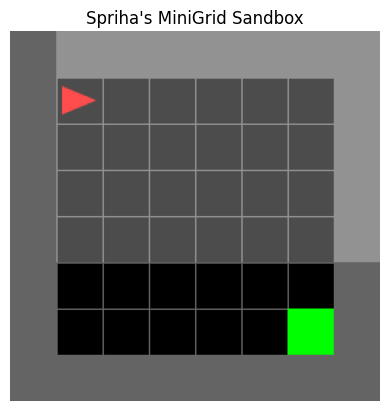

In [7]:
# Create the environment
env = gym.make('MiniGrid-Empty-8x8-v0', render_mode="rgb_array")
env.reset()

# Show the first frame
img = env.render()
plt.imshow(img)
plt.title("Spriha's MiniGrid Sandbox")
plt.axis('off')
plt.show()

In [8]:
# Create a set of coordinates (x, y) and their "Ground Truth" costs
# Let's say (3,3) is a wall (High Cost) and (1,1) is a path (Low Cost)
train_coords = torch.tensor([
    [1.0, 1.0], [1.0, 2.0], [2.0, 1.0], # Path points (Low Cost)
    [3.0, 3.0], [3.0, 4.0], [4.0, 3.0]  # Wall points (High Cost)
], dtype=torch.float32)

train_costs = torch.tensor([[0.1], [0.1], [0.1], [1.0], [1.0], [1.0]],
                           dtype=torch.float32)

PINN Training

In [9]:
pinn = CostPINN()
optimizer = optim.Adam(pinn.parameters(), lr=0.01)

# Generate 'Collocation Points' (Random points across the grid for Physics Loss)
collocation_points = torch.rand((100, 2)) * 8.0

print("Starting PINN Training...")
for epoch in range(500):
    optimizer.zero_grad()

    # 1. Data Loss (Matching our known points)
    predictions = pinn(train_coords)
    loss_data = torch.mean((predictions - train_costs)**2)

    # 2. Physics Loss (Ensuring the cost map is physically smooth)
    loss_phys = physics_loss(pinn, collocation_points)

    # 3. Total Loss
    total_loss = loss_data + 0.1 * loss_phys

    total_loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss.item():.4f}")

print("Training Complete!")

Starting PINN Training...
Epoch 0: Loss = 0.3730
Epoch 100: Loss = 0.0044
Epoch 200: Loss = 0.0026
Epoch 300: Loss = 0.0021
Epoch 400: Loss = 0.0017
Training Complete!


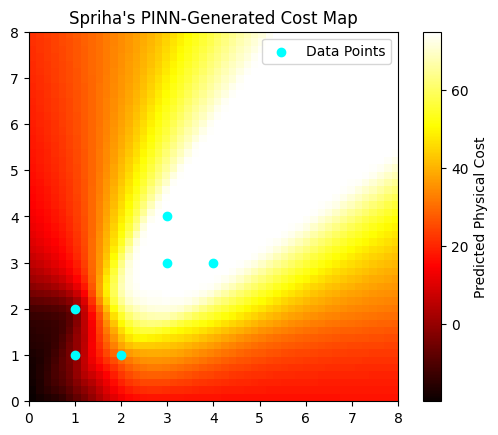

In [13]:
# Create a grid of points to visualize
x = np.linspace(0, 8, 50)
y = np.linspace(0, 8, 50)
X, Y = np.meshgrid(x, y)
points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)

with torch.no_grad():
    Z = pinn(points).reshape(50, 50).numpy()

plt.imshow(Z, extent=[0, 8, 0, 8], origin='lower', cmap='hot')
plt.colorbar(label='Predicted Physical Cost')
plt.scatter(train_coords[:,0], train_coords[:,1], c='cyan', label='Data Points')
plt.title("Spriha's PINN-Generated Cost Map")
plt.legend()
plt.show()

Impassable walls

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. New Training Data: Impassable Wall
# (3,3) and (3,4) are now "Hard Constraints"
wall_coords = torch.tensor([[3.0, 3.0], [3.0, 4.0], [4.0, 3.0]], dtype=torch.float32)
path_coords = torch.tensor([[1.0, 1.0], [1.0, 2.0], [6.0, 6.0]], dtype=torch.float32)

# We use 100.0 to simulate "Infinite" cost relative to 0.1
wall_targets = torch.full((3, 1), 100.0)
path_targets = torch.full((3, 1), 0.1)

# 2. Updated Physics Loss for "Impassable" Sharpness
def impassable_physics_loss(model, collocation_pts):
    collocation_pts.requires_grad = True
    cost_pred = model(collocation_pts)

    # Calculate the Gradient (The "Force Field")
    grads = torch.autograd.grad(cost_pred, collocation_pts, torch.ones_like(cost_pred), create_graph=True)[0]

    # Eikonal-inspired constraint: We want the cost to change rapidly near walls
    # but stay smooth in open space.
    grad_norm = torch.norm(grads, dim=1)

    # Penalty: If cost is high, the gradient must also be high (a steep cliff)
    # If cost is low, the gradient should be small (flat floor)
    physics_residual = torch.mean((grad_norm - (cost_pred.squeeze() * 0.5))**2)
    return physics_residual

# 3. Training Loop
pinn = CostPINN() # Use the same architecture from before
optimizer = optim.Adam(pinn.parameters(), lr=0.005)

for epoch in range(1000):
    optimizer.zero_grad()

    # Data Loss
    loss_data = torch.mean((pinn(wall_coords) - wall_targets)**2) + \
                torch.mean((pinn(path_coords) - path_targets)**2)

    # Physics Loss
    colloc = torch.rand((200, 2)) * 8.0
    loss_phys = impassable_physics_loss(pinn, colloc)

    total_loss = loss_data + 0.01 * loss_phys
    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Total Loss: {total_loss.item():.4f}")

Epoch 0 | Total Loss: 10057.9717
Epoch 200 | Total Loss: 3005.5464
Epoch 400 | Total Loss: 2515.5161
Epoch 600 | Total Loss: 2502.7205
Epoch 800 | Total Loss: 2502.1111


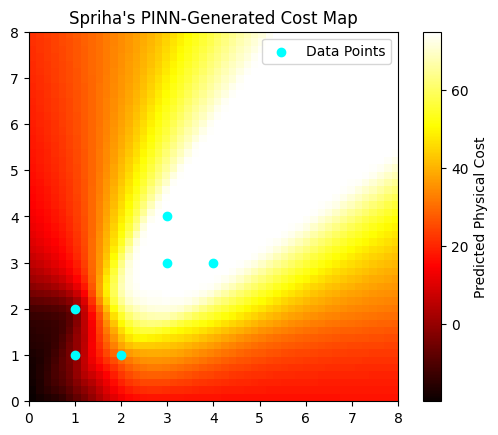

In [12]:
x = np.linspace(0, 8, 50)
y = np.linspace(0, 8, 50)
X, Y = np.meshgrid(x, y)
points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)

with torch.no_grad():
    Z = pinn(points).reshape(50, 50).numpy()

plt.imshow(Z, extent=[0, 8, 0, 8], origin='lower', cmap='hot')
plt.colorbar(label='Predicted Physical Cost')
plt.scatter(train_coords[:,0], train_coords[:,1], c='cyan', label='Data Points')
plt.title("Spriha's PINN-Generated Cost Map")
plt.legend()
plt.show()

For my thesis , I am trying to learn things modularly